# Tukey-Lambda Distribution

The **Tukey-Lambda distribution** is a one-parameter family used primarily as a **diagnostic tool** — not for modelling per se, but for identifying which symmetric distribution best fits a dataset using PPCC plots. By scanning λ values, you can determine whether your data has heavy, normal, or light tails.

| λ value | Approximates |
|---|---|
| λ = −1 | Cauchy (very heavy tails) |
| λ = 0 | Logistic |
| λ ≈ 0.14 | Normal |
| λ = 0.5 | U-shaped |
| λ = 1 | Uniform (−1, 1) |

| Property | Value |
|---|---|
| **Parameter** | λ (shape), μ (location), σ (scale) |
| **PPF (only explicit formula)** | G(p; λ) = [p^λ − (1−p)^λ] / λ |
| **PDF/CDF** | No closed form — computed from PPF numerically |
| **Symmetry** | Always symmetric — only models symmetric data |
| **Primary use** | PPCC plot — select best-fitting symmetric distribution |

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

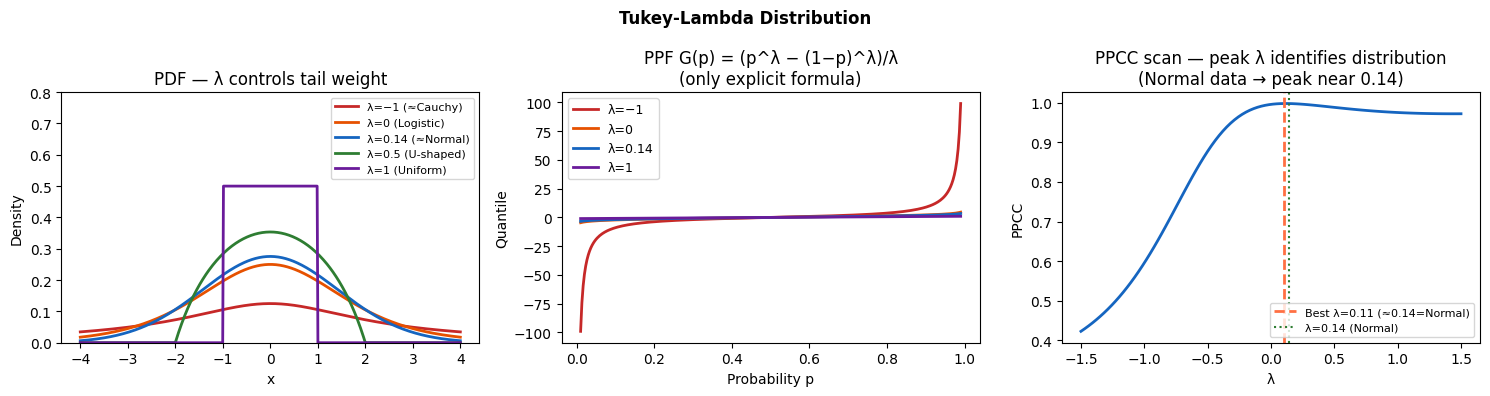

Best-fit λ = 0.106 (Normal expected: 0.14)


In [2]:
# scipy: stats.tukeylambda(lam)
x = np.linspace(-4, 4, 500)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Tukey-Lambda Distribution', fontsize=12, fontweight='bold')

# PDF for key lambda values
lambda_specs = [(-1,   '#C62828', 'λ=−1 (≈Cauchy)'),
                (0,    '#E65100', 'λ=0 (Logistic)'),
                (0.14, '#1565C0', 'λ=0.14 (≈Normal)'),
                (0.5,  '#2E7D32', 'λ=0.5 (U-shaped)'),
                (1,    '#6A1B9A', 'λ=1 (Uniform)')]
for lam, color, label in lambda_specs:
    try:
        y = stats.tukeylambda(lam).pdf(x)
        axes[0].plot(x, y, color=color, linewidth=2, label=label)
    except Exception:
        pass
axes[0].set_title('PDF — λ controls tail weight')
axes[0].set_xlabel('x'); axes[0].set_ylabel('Density')
axes[0].set_ylim(0, 0.8)
axes[0].legend(fontsize=8)

# PPF (only closed-form expression)
def tukey_ppf(p, lam):
    if abs(lam) < 1e-10:
        return np.log(p / (1-p))  # logistic
    return (p**lam - (1-p)**lam) / lam

p = np.linspace(0.01, 0.99, 300)
for lam, color, label in [(-1, '#C62828', 'λ=−1'), (0, '#E65100', 'λ=0'),
                            (0.14, '#1565C0', 'λ=0.14'), (1, '#6A1B9A', 'λ=1')]:
    axes[1].plot(p, tukey_ppf(p, lam), color=color, linewidth=2, label=label)
axes[1].set_title('PPF G(p) = (p^λ − (1−p)^λ)/λ\n(only explicit formula)')
axes[1].set_xlabel('Probability p'); axes[1].set_ylabel('Quantile')
axes[1].legend(fontsize=9)

# PPCC scan — find best λ for a dataset
np.random.seed(42)
data = stats.norm.rvs(size=200)
lambdas = np.linspace(-1.5, 1.5, 100)

def ppcc(data, lam):
    n = len(data)
    sorted_data = np.sort(data)
    p_vals = (np.arange(1, n+1) - 0.375) / (n + 0.25)
    theoretical = tukey_ppf(p_vals, lam)
    return np.corrcoef(sorted_data, theoretical)[0, 1]

correlations = [ppcc(data, lam) for lam in lambdas]
best_lam = lambdas[np.argmax(correlations)]

axes[2].plot(lambdas, correlations, color='#1565C0', linewidth=2)
axes[2].axvline(best_lam, color='#FF7043', linewidth=2, linestyle='--',
                label=f'Best λ={best_lam:.2f} (≈0.14=Normal)')
axes[2].axvline(0.14, color='#2E7D32', linewidth=1.5, linestyle=':',
                label='λ=0.14 (Normal)')
axes[2].set_title('PPCC scan — peak λ identifies distribution\n(Normal data → peak near 0.14)')
axes[2].set_xlabel('λ'); axes[2].set_ylabel('PPCC')
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.show()

print(f"Best-fit λ = {best_lam:.3f} (Normal expected: 0.14)")

## Key Takeaways

| | |
|---|---|
| **Diagnostic tool** | Primarily used for PPCC plots — not a modelling distribution |
| **λ < 0.14** | Heavy tails — Logistic (λ=0), Cauchy (λ=−1) |
| **λ = 0.14** | Normal tails |
| **λ > 0.14** | Light tails — Uniform (λ=1) |
| **PPCC scan** | Compute Q-Q correlation vs diagonal for each λ; peak = best fit |
| **Symmetric only** | Cannot diagnose skewed distributions — use Johnson system for asymmetric data |
| **PPF** | The only closed-form expression: G(p) = (p^λ − (1−p)^λ)/λ |